# SafeX Solutions — WhatsApp Auto-Reply Bot
## CRM Integration Module — Demo Notebook

**Group 53 · Week 2 individual contribution**

This notebook demonstrates the **CRM Integration** module end-to-end:

1. An inbound WhatsApp message comes in (simulated here, in production it arrives via the Twilio webhook in `app.py`).
2. `llm_helper.extract_lead_info()` uses **Groq's free LLM API** to pull out the lead's name, email, interest, status and sentiment.
3. `crm.CRMClient` **de-duplicates** the lead by phone number and **tags its pipeline status**, storing everything in a simple CSV "CRM sheet" (or Airtable, if configured).

Works in both **VS Code Jupyter** and **Google Colab** — see the setup cell below.


In [1]:
# ── Setup: works both in VS Code (files already on disk) and Google Colab ──
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # In Colab, upload config.py, crm.py, llm_helper.py, airtable_backend.py
    # (and optionally the data/ folder) using the file upload widget below,
    # OR clone your team's GitHub repo instead of uploading manually:
    #   !git clone https://github.com/<your-org>/<your-repo>.git
    #   %cd <your-repo>
    from google.colab import files
    needed = ["config.py", "crm.py", "llm_helper.py", "airtable_backend.py"]
    missing = [f for f in needed if not os.path.exists(f)]
    if missing:
        print("Please upload these files:", missing)
        uploaded = files.upload()

    !pip install -q groq python-dotenv twilio pyairtable
else:
    # VS Code / local Jupyter: just make sure dependencies are installed
    !pip install -q -r requirements.txt

print("Environment ready. IN_COLAB =", IN_COLAB)


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Environment ready. IN_COLAB = False


### 🔑 Add your free Groq API key

Get one in ~60 seconds at **https://console.groq.com** (no credit card needed).

Then either:
- set it as an environment variable before starting Jupyter, **or**
- paste it directly below for this demo session (don't commit it to git!).

If you skip this, the module automatically falls back to a lightweight
keyword/regex extractor so the whole pipeline still runs — just with less
nuanced status detection.


In [2]:
import os

# Paste your key between the quotes to try the real Groq extraction.
# Leave it empty to use the offline fallback extractor instead.
GROQ_KEY = ""   # e.g. "gsk_xxxxxxxxxxxxxxxxxxxxxxxx"

if GROQ_KEY:
    os.environ["GROQ_API_KEY"] = GROQ_KEY

os.environ.setdefault("GROQ_MODEL", "llama-3.1-8b-instant")
os.environ.setdefault("CRM_BACKEND", "csv")

import importlib
import config, crm, llm_helper
importlib.reload(config); importlib.reload(crm); importlib.reload(llm_helper)

from crm import CRMClient
from llm_helper import extract_lead_info, generate_auto_reply

print("Using Groq:", bool(os.environ.get("GROQ_API_KEY")))
print("CRM backend:", config.CRM_BACKEND)


Using Groq: False
CRM backend: csv


## 1. Sample inbound WhatsApp messages
This mirrors what Group 53's message-capture module hands off to this CRM module.

In [3]:
# Real inquiries reflecting SafeX Solutions' actual services (pulled from
# safexsolutions.com): Web Development, Cybersecurity, AI Automation,
# Digital Marketing, Creative Media, and the Skill Development Centre.
sample_messages = [
    {"name": "Ahmed Raza",     "phone": "+923011234567", "message": "Assalam o Alaikum, I visited your website. Do you build eCommerce websites for small businesses?"},
    {"name": "Ahmed Raza",     "phone": "+923011234567", "message": "Great, what's the estimated cost and timeline for a custom online store?"},
    {"name": "Mahnoor Sheikh", "phone": "+923021239876", "message": "Hi, I'm interested in your Cybersecurity Solutions for my company's network. Can you share more details?"},
    {"name": "Usman Ghani",    "phone": "+923034567891", "message": "Hello, we want to automate our customer support using AI. Does SafeX do AI Automation projects?"},
    {"name": "Usman Ghani",    "phone": "+923034567891", "message": "Perfect, please send a quote for an AI chatbot integrated with our CRM."},
    {"name": "Zoya Malik",     "phone": "+923045678912", "message": "hi"},
    {"name": "Zoya Malik",     "phone": "+923045678912", "message": "What digital marketing packages do you offer for Instagram growth?"},
    {"name": "Zoya Malik",     "phone": "+923045678912", "message": "Alright, let's proceed with the Digital Marketing package. My email is zoya.malik@brandhive.pk"},
    {"name": "Bilal Chaudhry", "phone": "+923078912345", "message": "Not interested at the moment, please remove my number from your list."},
]
for m in sample_messages:
    print(f"{m['name']:14s} | {m['phone']:16s} | {m['message']}")


Ahmed Raza     | +923011234567    | Assalam o Alaikum, I visited your website. Do you build eCommerce websites for small businesses?
Ahmed Raza     | +923011234567    | Great, what's the estimated cost and timeline for a custom online store?
Mahnoor Sheikh | +923021239876    | Hi, I'm interested in your Cybersecurity Solutions for my company's network. Can you share more details?
Usman Ghani    | +923034567891    | Hello, we want to automate our customer support using AI. Does SafeX do AI Automation projects?
Usman Ghani    | +923034567891    | Perfect, please send a quote for an AI chatbot integrated with our CRM.
Zoya Malik     | +923045678912    | hi
Zoya Malik     | +923045678912    | What digital marketing packages do you offer for Instagram growth?
Zoya Malik     | +923045678912    | Alright, let's proceed with the Digital Marketing package. My email is zoya.malik@brandhive.pk
Bilal Chaudhry | +923078912345    | Not interested at the moment, please remove my number from your list

## 2. Run each message through the pipeline
Extraction → de-duplication → status tagging, one message at a time.

In [4]:
crm_client = CRMClient()

for m in sample_messages:
    extraction = extract_lead_info(m["message"])
    lead, is_new = crm_client.add_or_update_lead(
        phone=m["phone"],
        message_text=m["message"],
        name=m["name"],
        email=extraction.get("email", ""),
        interest=extraction.get("interest", ""),
        status=extraction.get("status"),
        source="whatsapp",
    )
    reply = generate_auto_reply(m["message"], extraction)
    action = "CREATED " if is_new else "UPDATED "
    print(f"[{action}] {lead.name:12s} | status={lead.status:10s} | interest='{extraction['interest']}'")
    print(f"           bot reply -> {reply}\n")


[CREATED ] Ahmed Raza   | status=New        | interest='general inquiry'
           bot reply -> Thanks for reaching out to SafeX Solutions! 👋 Could you tell us a bit more about what you're looking for so we can help?

[UPDATED ] Ahmed Raza   | status=Qualified  | interest='pricing / demo inquiry'
           bot reply -> Great, we'd love to walk you through pricing and a quick demo. What's the best time to call you?

[CREATED ] Mahnoor Sheikh | status=New        | interest='general inquiry'
           bot reply -> Thanks for reaching out to SafeX Solutions! 👋 Could you tell us a bit more about what you're looking for so we can help?

[CREATED ] Usman Ghani  | status=New        | interest='general inquiry'
           bot reply -> Thanks for reaching out to SafeX Solutions! 👋 Could you tell us a bit more about what you're looking for so we can help?

[UPDATED ] Usman Ghani  | status=Qualified  | interest='pricing / demo inquiry'
           bot reply -> Great, we'd love to walk you throug

## 3. Inspect the resulting CRM sheet

Notice **Bilal Ahmed** and **Hina Riaz** only appear once each — the second
(and third) messages from the same phone number **updated** the existing
lead instead of creating a duplicate row, and Hina's status correctly
escalated from `New` → `Qualified` → `Converted` as her intent became clearer.


In [5]:
import pandas as pd

df = pd.DataFrame([l.to_row() for l in crm_client.get_all_leads()])
df = df[["name", "phone", "status", "interest", "message_count", "last_message"]]
df


,name,phone,status,interest,message_count,last_message
0,Ahmed Raza,+923011234567,Qualified,pricing / demo inquiry,2,"Great, what's the estimated cost and timeline ..."
1,Mahnoor Sheikh,+923021239876,New,general inquiry,1,"Hi, I'm interested in your Cybersecurity Solut..."
2,Usman Ghani,+923034567891,Qualified,pricing / demo inquiry,2,"Perfect, please send a quote for an AI chatbot..."
3,Zoya Malik,+923045678912,Converted,ready to purchase,3,"Alright, let's proceed with the Digital Market..."
4,Bilal Chaudhry,+923078912345,Lost,opted out,1,"Not interested at the moment, please remove my..."


## 4. Pipeline summary (what the dashboard's stat cards show)

In [6]:
stats = crm_client.stats()
stats


{'total': 5,
 'new': 1,
 'contacted': 0,
 'qualified': 2,
 'converted': 1,
 'lost': 1}

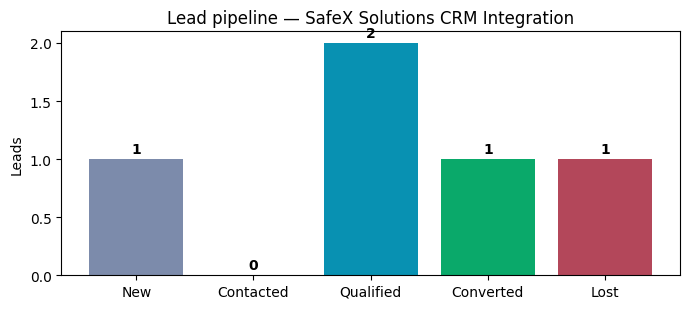

In [7]:
import matplotlib.pyplot as plt

order = ["new", "contacted", "qualified", "converted", "lost"]
values = [stats.get(k, 0) for k in order]
colors = ["#7c8bab", "#2f5dff", "#0891b2", "#0aa96a", "#b3475a"]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar([k.capitalize() for k in order], values, color=colors)
ax.set_title("Lead pipeline — SafeX Solutions CRM Integration")
ax.set_ylabel("Leads")
for i, v in enumerate(values):
    ax.text(i, v + 0.05, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 5. De-duplication check (edge case)

Sending an identical phone number again should **update** the same lead,
never create a second row — this is the core requirement from the
assignment scope ("Connect captured leads to a simple CRM sheet ... with
de-duplication and status tagging").


In [8]:
before_count = len(crm_client.get_all_leads())

extraction = extract_lead_info("Just checking in, any update?")
lead, is_new = crm_client.add_or_update_lead(
    phone="+923045678912",  # same as Zoya Malik above, already Converted
    message_text="Just checking in, any update?",
    status=extraction.get("status"),
)

after_count = len(crm_client.get_all_leads())

print("Lead count before:", before_count)
print("Lead count after: ", after_count)
print("Is new lead?      ", is_new, "(should be False)")
print("Zoya's status stayed at:", lead.status, "(Converted leads never get downgraded by a casual follow-up)")
assert before_count == after_count, "De-duplication failed - a duplicate row was created!"
assert lead.status == "Converted", "Status was incorrectly downgraded!"
print("\n✅ De-duplication and status-protection both verified.")


Lead count before: 5
Lead count after:  5
Is new lead?       False (should be False)
Zoya's status stayed at: Converted (Converted leads never get downgraded by a casual follow-up)

✅ De-duplication and status-protection both verified.


## 6. Where this fits in the full bot (Flask + Twilio)

This notebook exercises the same `crm.py` / `llm_helper.py` code that
`app.py` uses in production:

```
WhatsApp user
     │
     ▼
Twilio WhatsApp Sandbox  ── POST /webhook ──▶  app.py (Flask)
                                                   │
                                                   ▼
                                        llm_helper.extract_lead_info()
                                                   │
                                                   ▼
                                        crm.CRMClient.add_or_update_lead()
                                                   │
                                       ┌───────────┴───────────┐
                                       ▼                       ▼
                              data/leads.csv            (or Airtable base)
                                       │
                                       ▼
                         Dashboard at http://localhost:5000
                     (blue/black/white themed live CRM view)
```

To run the full app with the dashboard UI:

```bash
pip install -r requirements.txt
cp .env.example .env      # add your GROQ_API_KEY
python app.py
# open http://127.0.0.1:5000
```

See **README.md** for the complete setup, Twilio sandbox connection steps,
and how this module hands off to the rest of Group 53's bot.
